# Model Training and Evaluation

This notebook focuses on training and evaluating multiple machine learning models for human activity recognition. The objective is to identify the model that achieves the best overall classification performance.

## Importing Libraries

The necessary machine learning and visualisation libraries are imported to prepare, train, and evaluate the models.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/train.csv")

df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


## Target separation and Validation Split

The dataset is divided into predictor variables (X) and the target activity labels (y).
The training dataset is split into training and validation subsets. The training set is used to fit the models, while the validation set is used to evaluate their performance on unseen data.

In [3]:
X = df.drop("Activity", axis=1)
y = df["Activity"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Feature Scaling

Feature scaling is applied to models that are sensitive to feature magnitudes, such as K-Nearest Neighbours and Support Vector Machines.

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## Model Evaluation Function

A reusable evaluation function is created to ensure each model is trained and assessed using the same methodology and performance metrics.

In [5]:
def evaluate_model(model, X_train, X_val, y_train, y_val):
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average="macro")

    print(model.__class__.__name__)
    print("Accuracy:", acc)
    print("F1 (macro):", f1)
    print("-" * 40)

    return acc, f1, preds

## Logistic Regression

Logistic Regression is used as a baseline model due to its simplicity and efficiency for classification tasks.

In [6]:
lr = LogisticRegression(max_iter=10000)
lr_acc, lr_f1, lr_pred = evaluate_model(
    lr,
    X_train_scaled,
    X_val_scaled,
    y_train,
    y_val
)

LogisticRegression
Accuracy: 0.9850441876274643
F1 (macro): 0.9861997405966277
----------------------------------------


## K-Nearest Neighbours (KNN)

KNN classifies activities based on similarity to nearby observations in the feature space.

In [7]:
knn = KNeighborsClassifier(n_neighbors=5)
knn_acc, knn_f1, knn_pred = evaluate_model(
    knn,
    X_train_scaled,
    X_val_scaled,
    y_train,
    y_val
)

KNeighborsClassifier
Accuracy: 0.9653297076818491
F1 (macro): 0.9673008194913195
----------------------------------------


## Support Vector Machine (SVM)

SVM attempts to find the optimal decision boundaries that separate activity classes.

In [8]:
svm = SVC()
svm_acc, svm_f1, svm_pred = evaluate_model(
    svm,
    X_train_scaled,
    X_val_scaled,
    y_train,
    y_val
)

SVC
Accuracy: 0.9796057104010877
F1 (macro): 0.9811934389140271
----------------------------------------


## Random Forest

Random Forest is an ensemble learning method that combines multiple decision trees to improve predictive performance and robustness.

In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_acc, rf_f1, rf_pred = evaluate_model(
    rf,
    X_train,
    X_val,
    y_train,
    y_val
)

RandomForestClassifier
Accuracy: 0.9870836165873556
F1 (macro): 0.987172817045629
----------------------------------------


## Gradient Boosting

Gradient Boosting builds trees sequentially, allowing each new tree to correct errors made by previous trees.

In [10]:
gb = GradientBoostingClassifier()
gb_acc, gb_f1, gb_pred = evaluate_model(
    gb,
    X_train,
    X_val,
    y_train,
    y_val
)

GradientBoostingClassifier
Accuracy: 0.9870836165873556
F1 (macro): 0.9877098028840909
----------------------------------------


## Model Comparison

The models are compared using accuracy and macro F1-score. Macro F1-score is used as the primary metric because it provides a balanced assessment across all activity classes.

In [11]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        lr_acc, knn_acc, svm_acc, rf_acc, gb_acc
    ],
    "F1 Score": [
        lr_f1, knn_f1, svm_f1, rf_f1, gb_f1
    ]
})

In [12]:
results.sort_values("F1 Score", ascending=False)

,Model,Accuracy,F1 Score
4,Gradient Boosting,0.987084,0.987710
3,Random Forest,0.987084,0.987173
0,Logistic Regression,0.985044,0.986200
2,SVM,0.979606,0.981193
1,KNN,0.965330,0.967301


In [13]:
best_model_name = results.sort_values("F1 Score", ascending=False).iloc[0]["Model"]
print("Best model:", best_model_name)

Best model: Gradient Boosting


## Best Model Selection

After comparing all models using macro F1-score and accuracy, Gradient Boosting was selected as the best-performing model. Its strong performance across all activity classes demonstrates its ability to capture complex patterns within the smartphone sensor data.

In [21]:
best_preds = gb_pred
best_model = gb

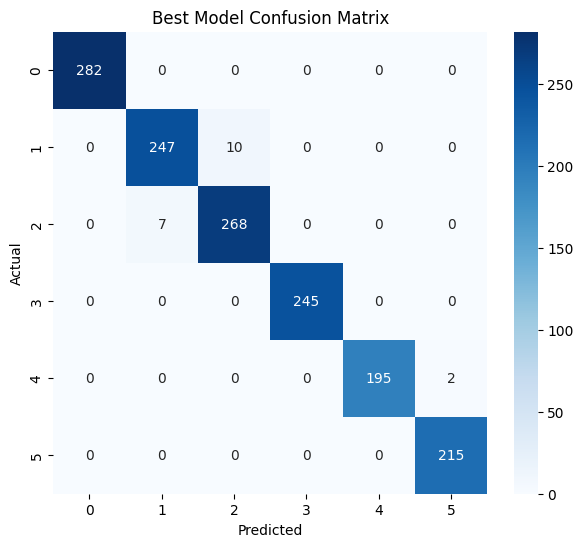

In [22]:
cm = confusion_matrix(y_val, best_preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Best Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Classification Report Analysis

The Gradient Boosting model achieved excellent performance, with an accuracy and macro F1-score of approximately 0.99. Most activities were classified almost perfectly, with only minor confusion between similar activities such as Sitting and Standing. Overall, the model demonstrated strong and consistent performance across all activity classes.

In [23]:
print(classification_report(y_val, best_preds))

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       282
           SITTING       0.97      0.96      0.97       257
          STANDING       0.96      0.97      0.97       275
           WALKING       1.00      1.00      1.00       245
WALKING_DOWNSTAIRS       1.00      0.99      0.99       197
  WALKING_UPSTAIRS       0.99      1.00      1.00       215

          accuracy                           0.99      1471
         macro avg       0.99      0.99      0.99      1471
      weighted avg       0.99      0.99      0.99      1471



In [26]:
importances = gb.feature_importances_

feature_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending =False
)

feature_df.head(10)

,Feature,Importance
52,tGravityAcc-min()-X,0.262428
50,tGravityAcc-max()-Y,0.054954
504,fBodyAccMag-mad(),0.053857
559,"angle(Y,gravityMean)",0.046739
9,tBodyAcc-max()-X,0.040562
503,fBodyAccMag-std(),0.031941
296,fBodyAcc-skewness()-X,0.030890
302,"fBodyAcc-bandsEnergy()-1,8",0.029957
166,tBodyGyroJerk-mad()-X,0.029731
41,tGravityAcc-mean()-Y,0.024305


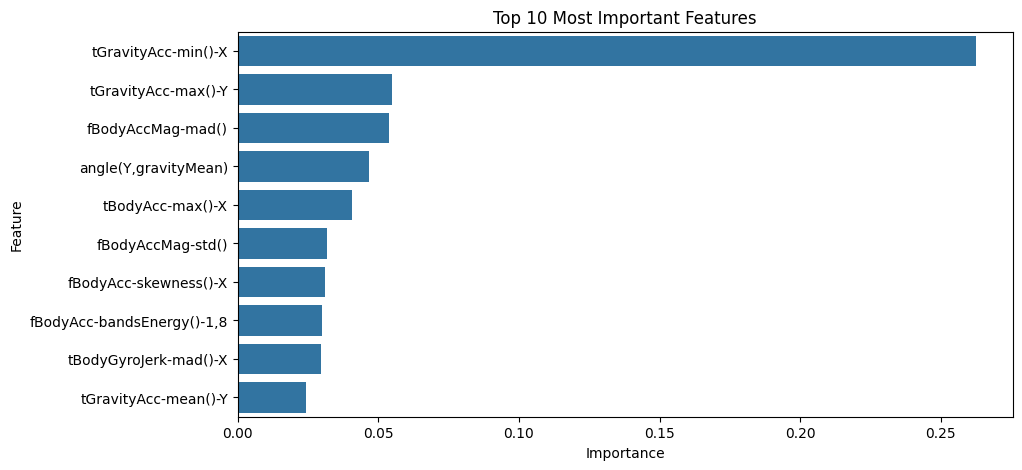

In [27]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=feature_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.show()

## Feature Importance Analysis

Gradient Boosting feature importance scores show that a small number of features contribute disproportionately to the model's predictions. The most important feature, `tGravityAcc-min()-X`, accounts for over 26% of the total importance, suggesting that gravity-based acceleration measurements are highly informative for distinguishing between activities.

Several other important features relate to body acceleration, acceleration magnitude, and body orientation relative to gravity. This indicates that both movement intensity and device orientation play a key role in accurately recognising human activities.

The distribution of importance scores is relatively concentrated, meaning the model relies heavily on a small set of highly predictive features rather than using all features equally.

In [20]:
import joblib

joblib.dump(rf, "../models/random_forest.pkl")
joblib.dump(knn, "../models/knn.pkl")

['../models/knn.pkl']

## Model Export

The best-performing Gradient Boosting model and the Random Forest model were saved as `.pkl` files. Saving trained models allows them to be reused for future predictions without requiring retraining.

## Conclusion

This project evaluated multiple machine learning algorithms for human activity recognition using smartphone sensor data. Gradient Boosting achieved the highest overall performance, producing a macro F1-score of approximately 0.99 across six activity classes. The results demonstrate that smartphone sensor features can be used to accurately classify daily activities, while feature importance analysis provided insight into which measurements contributed most to model performance.